# EDA

Сначала просто смотрю, что вообще лежит в данных и где могут быть полезные признаки. Пока действуем без сложных моделей, хочу понять классы, время, события и не потерять что-нибудь важное на старте работы с кейсом

In [1]:
from pathlib import Path

import pandas as pd

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)

PROJECT_ROOT: /Users/an.m.titova/Documents/bot_detection_case
DATA_DIR: /Users/an.m.titova/Documents/bot_detection_case/data


In [3]:
train_path = DATA_DIR / "train.csv"

print(train_path)
print(train_path.exists())

/Users/an.m.titova/Documents/bot_detection_case/data/train.csv
True


In [4]:
train = pd.read_csv(
    train_path,
    parse_dates=[
        "cookie_created_at",
        "window_start_ts",
        "window_end_ts",
    ],
)
train.head()
train.shape
train.columns
train.info()
train.isna().sum()

train["target"].value_counts()
train["target"].mean()

<class 'pandas.DataFrame'>
RangeIndex: 11091 entries, 0 to 11090
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   cookie_id          11091 non-null  str           
 1   cookie_created_at  11091 non-null  datetime64[us]
 2   window_start_ts    11091 non-null  datetime64[us]
 3   window_end_ts      11091 non-null  datetime64[us]
 4   target             11091 non-null  int64         
dtypes: datetime64[us](3), int64(1), str(1)
memory usage: 433.4 KB


np.float64(0.0810567126498963)

Сразу видно, что ботов мало, около 8%.

Значит метрика accuracy тут вообще мимо и на нее не смотрим. Можно почти всех назвать людьми и получить красивое значение accuracy, но мы так делать не будем хехе

In [5]:
train["window_duration"] = (
    train["window_end_ts"] - train["window_start_ts"]
)

train["window_duration"].value_counts()
print("Первое окно:")
print(train["window_start_ts"].min())

print("\nПоследнее окно:")
print(train["window_start_ts"].max())

Первое окно:
2026-04-06 00:00:00

Последнее окно:
2026-04-19 00:00:00


In [6]:
target_by_day = (
    train
    .groupby("window_start_ts")
    .agg(
        n_cookies=("cookie_id", "size"),
        n_bots=("target", "sum"),
        bot_share=("target", "mean"),
    )
)

target_by_day

,n_cookies,n_bots,bot_share
window_start_ts,,,
2026-04-06,772,68,0.088083
2026-04-07,797,59,0.074028
2026-04-08,834,70,0.083933
2026-04-09,902,66,0.073171
2026-04-10,912,82,0.089912
2026-04-11,896,79,0.088170
2026-04-12,817,67,0.082007
2026-04-13,843,53,0.062871
2026-04-14,826,70,0.084746


In [7]:
print("Самая старая cookie:")
print(train["cookie_created_at"].min())

print("\nСамая новая cookie:")
print(train["cookie_created_at"].max())

Самая старая cookie:
2025-01-22 17:09:47

Самая новая cookie:
2026-04-18 22:45:04


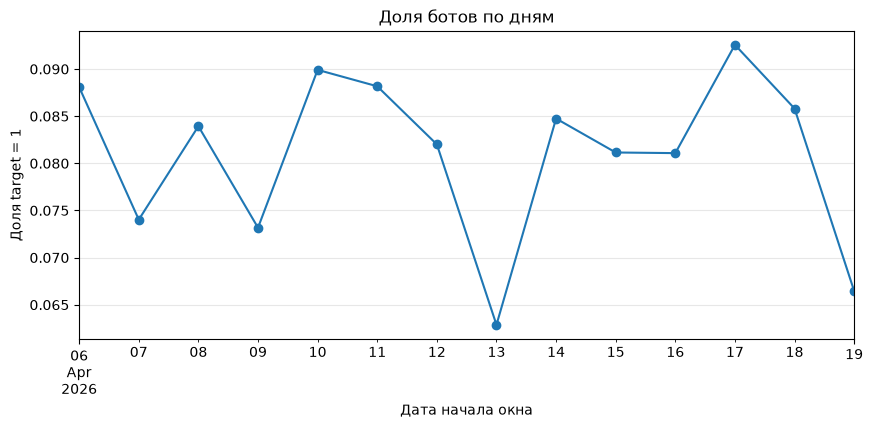

In [8]:
import matplotlib.pyplot as plt

target_by_day["bot_share"].plot(
    figsize=(10, 4),
    marker="o",
)

plt.title("Доля ботов по дням")
plt.xlabel("Дата начала окна")
plt.ylabel("Доля target = 1")
plt.grid(alpha=0.3)
plt.show()

По дням доля ботов неравномерно распределена, какого-то одного дня с совсем странным скачком нет

In [9]:
train["cookie_age_days"] = (
    train["window_start_ts"] - train["cookie_created_at"]
).dt.total_seconds() / (24 * 60 * 60)

In [10]:
train["cookie_age_days"].describe()

count    11091.000000
mean        71.867225
std         66.993073
min          0.012361
25%         13.114740
50%         59.759178
75%        108.552766
max        449.284873
Name: cookie_age_days, dtype: float64

In [11]:
train.groupby("target")["cookie_age_days"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,10192.0,73.908394,66.970965,0.014502,18.850226,61.782367,110.44640,449.284873
1,899.0,48.726411,62.795697,0.012361,0.943495,18.968403,83.45294,361.764005


Тут уже есть нормальное наблюдение. У людей медианный возраст куки около 62 дней, у ботов около 19. Еще у четверти ботов куки вообще младше примерно одного дня
Возраст точно можно дать модели как признак. Но делать правило по типу маленькая по дням куки = бот нельзя, распределения сильно пересекаются

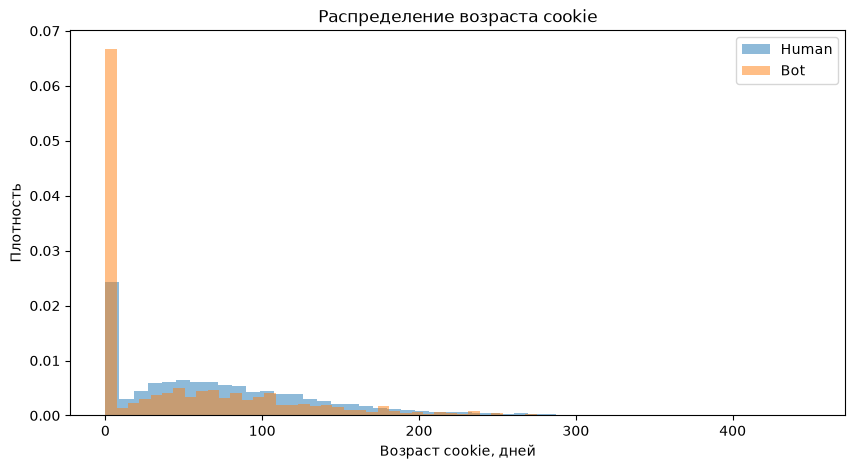

In [12]:
plt.figure(figsize=(10, 5))

for target, label in [(0, "Human"), (1, "Bot")]:
    train.loc[
        train["target"] == target,
        "cookie_age_days"
    ].plot(
        kind="hist",
        bins=50,
        density=True,
        alpha=0.5,
        label=label,
    )

plt.xlabel("Возраст cookie, дней")
plt.ylabel("Плотность")
plt.title("Распределение возраста cookie")
plt.legend()
plt.show()

In [13]:
test = pd.read_csv(
    DATA_DIR / "test.csv",
    parse_dates=[
        "cookie_created_at",
        "window_start_ts",
        "window_end_ts",
    ],
)

test.head()

,cookie_id,cookie_created_at,window_start_ts,window_end_ts
0,ck_315fb710a0e371e7,2026-02-20 08:52:31,2026-04-20,2026-04-21
1,ck_a76ee3b3e3e522fd,2026-01-19 13:42:15,2026-04-20,2026-04-21
2,ck_94c9a4d382689e82,2026-04-19 06:28:37,2026-04-20,2026-04-21
3,ck_8eaf9509ad9462a0,2026-01-19 17:18:06,2026-04-20,2026-04-21
4,ck_9a88a5a989cb5bc6,2025-11-09 17:25:13,2026-04-20,2026-04-21


In [14]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("\nTrain columns:")
print(train.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

Train shape: (11091, 7)
Test shape: (4909, 4)

Train columns:
['cookie_id', 'cookie_created_at', 'window_start_ts', 'window_end_ts', 'target', 'window_duration', 'cookie_age_days']

Test columns:
['cookie_id', 'cookie_created_at', 'window_start_ts', 'window_end_ts']


In [15]:
print("Пропуски:")
display(test.isna().sum())

print("Дубликаты cookie_id:", test["cookie_id"].duplicated().sum())

print("Уникальных cookie:", test["cookie_id"].nunique())
assert test["cookie_id"].is_unique

print(
    "TRAIN:",
    train["window_start_ts"].min(),
    "->",
    train["window_start_ts"].max(),
)

print(
    "TEST:",
    test["window_start_ts"].min(),
    "->",
    test["window_start_ts"].max(),
)

Пропуски:


cookie_id            0
cookie_created_at    0
window_start_ts      0
window_end_ts        0
dtype: int64

Дубликаты cookie_id: 0
Уникальных cookie: 4909
TRAIN: 2026-04-06 00:00:00 -> 2026-04-19 00:00:00
TEST: 2026-04-20 00:00:00 -> 2026-04-26 00:00:00


In [16]:
test["cookie_age_days"] = (
    test["window_start_ts"] - test["cookie_created_at"]
).dt.total_seconds() / (24 * 60 * 60)
test["cookie_age_days"].describe()

count    4909.000000
mean       71.647038
std        67.999234
min         0.020324
25%        12.138646
50%        58.631076
75%       107.642708
max       465.293692
Name: cookie_age_days, dtype: float64

Train заканчивается 19 апреля, а test начинается 20 апреля. Поэтому случайный split делать не стоит, он перемешает прошлое и будущее. Дальше буду проверять модели по времени

In [17]:
events = pd.read_csv(
    DATA_DIR / "events.csv.gz",
    parse_dates=["event_ts"],
)

events.head()

,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
0,ck_5efbea1befdefe1b,2026-04-26 09:11:24,200,item_view,desktop,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1027450.0,elektronika,kaliningrad,pro,NaN,NaN,NaN,NaN
1,ck_c4ca1434f3778f1d,2026-04-20 14:04:31,100,search_results_view,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,telefony,habarovsk,NaN,iphone 13 128,4.0,NaN,NaN
2,ck_d274382b19488771,2026-04-13 12:02:56,200,item_view,WEB,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1048743.0,kvartiry_prodazha,kirov,private,NaN,NaN,675.0,276.0
3,ck_fbbed2ff14944ce9,2026-04-08 06:12:14,100,search_results_view,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,bytovaya_tehnika,novosibirsk,NaN,пылесос dyson,2.0,NaN,NaN
4,ck_56cc15c7c634cb9f,2026-04-12 17:16:05,100,search_results_view,WEB,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,odezhda,sankt-peterburg,NaN,костюм мужской,2.0,NaN,NaN


In [18]:
events.shape
events.info()

<class 'pandas.DataFrame'>
RangeIndex: 328905 entries, 0 to 328904
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   cookie_id      328905 non-null  str           
 1   event_ts       328905 non-null  datetime64[us]
 2   eid            328905 non-null  int64         
 3   event_name     328905 non-null  str           
 4   platform       328905 non-null  str           
 5   user_agent     328905 non-null  str           
 6   item_id        214308 non-null  float64       
 7   item_category  295985 non-null  str           
 8   item_location  305112 non-null  str           
 9   seller_type    195052 non-null  str           
 10  search_query   100402 non-null  str           
 11  search_page    100402 non-null  float64       
 12  pointer_x      108540 non-null  float64       
 13  pointer_y      108540 non-null  float64       
dtypes: datetime64[us](1), float64(4), int64(1), str(8)
memory usage

In [19]:
events["event_name"].value_counts(normalize=True)

event_name
item_view               0.367331
search_results_view     0.305261
photo_swipe             0.111026
favorite_add            0.057916
seller_page_view        0.052912
contact_phone_show      0.034405
captcha_shown           0.024104
login                   0.019054
contact_chat_open       0.018622
contact_message_sent    0.009367
Name: proportion, dtype: float64

In [20]:
missing = pd.DataFrame({
    "missing_count": events.isna().sum(),
    "missing_share": events.isna().mean(),
}).sort_values("missing_share", ascending=False)

missing

,missing_count,missing_share
search_query,228503,0.694739
search_page,228503,0.694739
pointer_x,220365,0.669996
pointer_y,220365,0.669996
seller_type,133853,0.406966
item_id,114597,0.348420
item_category,32920,0.100090
item_location,23793,0.072340
cookie_id,0,0.000000
event_ts,0,0.000000


In [21]:
events["platform_clean"] = (
    events["platform"]
    .astype("string")
    .str.strip()
    .str.lower()
)
events["platform_clean"].value_counts(dropna=False)

platform_clean
web        138792
android    126875
desktop     46866
ios         12269
iphone       4103
Name: count, dtype: Int64

In [22]:
print(
    "Cookie в events:",
    events["cookie_id"].nunique()
)

print(
    "Train + test:",
    train["cookie_id"].nunique()
    + test["cookie_id"].nunique()
)

Cookie в events: 16000
Train + test: 16000


In [23]:
meta_cookie_ids = set(train["cookie_id"]) | set(test["cookie_id"])
event_cookie_ids = set(events["cookie_id"])

print(
    "Cookie без событий:",
    len(meta_cookie_ids - event_cookie_ids)
)

print(
    "Лишние cookie в events:",
    len(event_cookie_ids - meta_cookie_ids)
)

Cookie без событий: 0
Лишние cookie в events: 0


С events все хорошо, все 16000 куки на месте, куки без событий нет. Ура, хотя бы тут ничего не потерялось :))
Пропусков много, но они выглядят логично. Например, search_query есть только там, где вообще был поиск, pointer тоже заполнен не для каждого события

In [24]:
meta = pd.concat(
    [
        train[
            [
                "cookie_id",
                "window_start_ts",
                "window_end_ts",
            ]
        ].assign(split="train"),

        test[
            [
                "cookie_id",
                "window_start_ts",
                "window_end_ts",
            ]
        ].assign(split="test"),
    ],
    ignore_index=True,
)

events_with_window = events.merge(
    meta,
    on="cookie_id",
    how="inner",
    validate="many_to_one",
)

in_window = (
    (events_with_window["event_ts"] >=
     events_with_window["window_start_ts"])
    &
    (events_with_window["event_ts"] <
     events_with_window["window_end_ts"])
)

events_valid = events_with_window.loc[in_window].copy()

print("Все события:", len(events))
print("События внутри окна:", len(events_valid))
print("События вне окна:", (~in_window).sum())

Все события: 328905
События внутри окна: 288126
События вне окна: 40779


In [25]:
events_train = events_valid[
    events_valid["split"] == "train"
].copy()

events_test = events_valid[
    events_valid["split"] == "test"
].copy()

print("Train events:", len(events_train))
print("Test events:", len(events_test))

Train events: 198436
Test events: 89690


In [26]:
events_train[
    events_train["event_name"] == "captcha_shown"
].shape

(0, 18)

In [27]:
print(
    "Полных дубликатов:",
    events_valid.duplicated().sum()
)

Полных дубликатов: 4293


In [28]:
event_columns = events.columns.tolist()

print(
    "Полных дубликатов среди разрешённых событий:",
    events_valid[event_columns].duplicated().sum()
)

Полных дубликатов среди разрешённых событий: 4293


Нашлось 4293 полных дубля событий. Это уже стоит взять во внимание. Если оставить их как есть, они могут раздуть количество событий и испортить временные признаки. Позже посчитаю дубли отдельным признаком и уберу их из основных агрегатов

In [29]:
events_per_cookie = (
    events_train
    .groupby("cookie_id")
    .size()
    .rename("n_events")
    .reset_index()
)

events_per_cookie = events_per_cookie.merge(
    train[["cookie_id", "target"]],
    on="cookie_id",
    how="left",
)

events_per_cookie.groupby("target")["n_events"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,10192.0,16.869015,16.173297,1.0,6.0,12.0,22.0,140.0
1,899.0,29.484983,27.515182,1.0,11.0,20.0,38.0,169.0


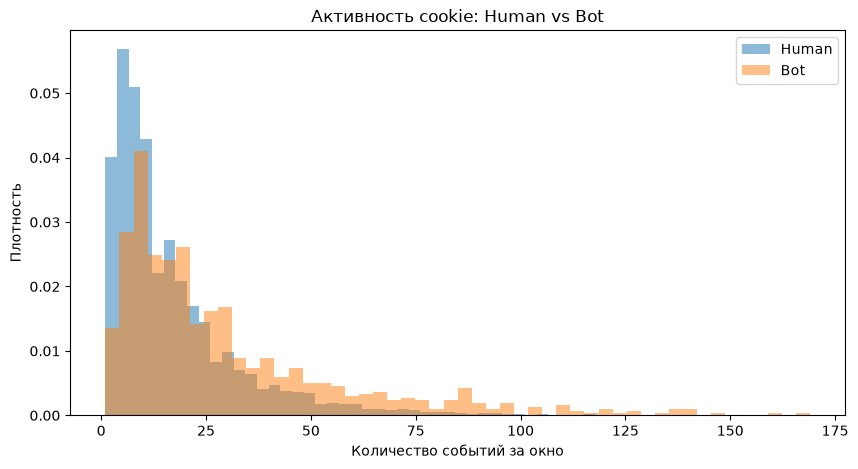

In [30]:
plt.figure(figsize=(10, 5))

for target, label in [(0, "Human"), (1, "Bot")]:
    events_per_cookie.loc[
        events_per_cookie["target"] == target,
        "n_events",
    ].plot(
        kind="hist",
        bins=50,
        density=True,
        alpha=0.5,
        label=label,
    )

plt.xlabel("Количество событий за окно")
plt.ylabel("Плотность")
plt.title("Активность cookie: Human vs Bot")
plt.legend()
plt.show()

Боты в среднем активнее! медиана около 20 событий против 12 у людей
Разница есть, но опять же не такая, чтобы классифицировать только по `n_events`. Добавим его как один из признаков

In [31]:
print("Всего cookie в train:", train["cookie_id"].nunique())
print("Cookie с событиями в окне:", events_train["cookie_id"].nunique())

event_counts = (
    pd.crosstab(
        events_train["cookie_id"],
        events_train["event_name"],
    )
    .add_prefix("cnt_event_")
)

event_counts.head()

Всего cookie в train: 11091
Cookie с событиями в окне: 11091


event_name,cnt_event_contact_chat_open,cnt_event_contact_message_sent,cnt_event_contact_phone_show,cnt_event_favorite_add,cnt_event_item_view,cnt_event_login,cnt_event_photo_swipe,cnt_event_search_results_view,cnt_event_seller_page_view
cookie_id,,,,,,,,,
ck_000c95f1408dcb00,0,0,0,0,11,0,1,3,1
ck_000e8c52636e3bec,0,0,1,4,11,1,5,9,3
ck_0010e31baa4a1fb7,0,0,0,2,7,1,1,4,1
ck_0010ec3874fb5378,0,0,0,10,25,1,14,20,4
ck_001722063b94cae0,0,0,1,0,8,0,1,5,0


In [32]:
event_counts.columns

Index(['cnt_event_contact_chat_open', 'cnt_event_contact_message_sent',
       'cnt_event_contact_phone_show', 'cnt_event_favorite_add',
       'cnt_event_item_view', 'cnt_event_login', 'cnt_event_photo_swipe',
       'cnt_event_search_results_view', 'cnt_event_seller_page_view'],
      dtype='str', name='event_name')

In [33]:
train_event_features = (
    train[["cookie_id", "target"]]
    .merge(
        event_counts.reset_index(),
        on="cookie_id",
        how="left",
    )
)

count_cols = [
    col for col in train_event_features.columns
    if col.startswith("cnt_event_")
]

train_event_features[count_cols] = (
    train_event_features[count_cols]
    .fillna(0)
)

train_event_features["n_events"] = (
    train_event_features[count_cols].sum(axis=1)
)
train_event_features.head()

,cookie_id,target,cnt_event_contact_chat_open,cnt_event_contact_message_sent,cnt_event_contact_phone_show,cnt_event_favorite_add,cnt_event_item_view,cnt_event_login,cnt_event_photo_swipe,cnt_event_search_results_view,cnt_event_seller_page_view,n_events
0,ck_54a059eb7d3ea68b,0,0,0,0,0,3,0,1,3,0,7
1,ck_7e4de46eeab82974,0,0,0,1,1,22,1,4,8,4,41
2,ck_9320229ef6304522,0,1,1,2,3,7,3,3,13,3,36
3,ck_30ccd25bc1714ed9,0,1,0,1,0,14,0,0,3,2,21
4,ck_a77c5f05948cdeef,0,0,0,1,2,13,0,4,6,3,29


In [34]:
train_event_features["n_event_types"] = (
    (train_event_features[count_cols] > 0)
    .sum(axis=1)
)

In [35]:
event_means = (
    train_event_features
    .groupby("target")[count_cols]
    .mean()
    .T
)

event_means.columns = ["human_mean", "bot_mean"]

event_means["bot_minus_human"] = (
    event_means["bot_mean"]
    - event_means["human_mean"]
)

event_means.sort_values(
    "bot_minus_human",
    ascending=False,
)

,human_mean,bot_mean,bot_minus_human
cnt_event_item_view,6.158752,12.867631,6.708879
cnt_event_search_results_view,5.141189,10.364850,5.223661
cnt_event_seller_page_view,0.895310,1.738598,0.843288
cnt_event_contact_phone_show,0.624117,0.761958,0.137841
cnt_event_contact_chat_open,0.333987,0.418242,0.084255
cnt_event_contact_message_sent,0.173568,0.233593,0.060025
cnt_event_photo_swipe,2.069368,2.068966,-0.000403
cnt_event_login,0.362343,0.230256,-0.132087
cnt_event_favorite_add,1.110381,0.800890,-0.309491


In [36]:
for col in count_cols:
    share_col = col.replace("cnt_event_", "share_event_")

    train_event_features[share_col] = (
        train_event_features[col]
        / train_event_features["n_events"].replace(0, pd.NA)
    )

In [37]:
share_cols = [
    col for col in train_event_features.columns
    if col.startswith("share_event_")
]

train_event_features[share_cols] = (
    train_event_features[share_cols]
    .fillna(0)
)

In [38]:
share_means = (
    train_event_features
    .groupby("target")[share_cols]
    .mean()
    .T
)

share_means.columns = ["human_mean", "bot_mean"]

share_means["difference"] = (
    share_means["bot_mean"]
    - share_means["human_mean"]
)

share_means.sort_values(
    "difference",
    ascending=False,
)

,human_mean,bot_mean,difference
share_event_item_view,0.364250,0.424916,0.060666
share_event_search_results_view,0.308472,0.331261,0.022788
share_event_seller_page_view,0.052861,0.061046,0.008184
share_event_contact_phone_show,0.030725,0.033282,0.002557
share_event_contact_message_sent,0.008091,0.010416,0.002325
share_event_contact_chat_open,0.016645,0.018093,0.001449
share_event_login,0.023179,0.009808,-0.013372
share_event_favorite_add,0.068735,0.033013,-0.035721
share_event_photo_swipe,0.127041,0.078164,-0.048876


In [39]:
train_event_features.groupby("target")[
    ["n_events", "n_event_types"]
].describe()

n_events                                                      \
          count       mean        std  min   25%   50%   75%    max   
target                                                                
0       10192.0  16.869015  16.173297  1.0   6.0  12.0  22.0  140.0   
1         899.0  29.484983  27.515182  1.0  11.0  20.0  38.0  169.0   

       n_event_types                                               
               count      mean       std  min  25%  50%  75%  max  
target                                                             
0            10192.0  4.598312  1.915840  1.0  3.0  4.0  6.0  9.0  
1              899.0  4.803115  1.634862  1.0  4.0  5.0  6.0  9.0

In [40]:
event_presence = (
    train_event_features
    .groupby("target")[count_cols]
    .apply(lambda x: (x > 0).mean())
    .T
)

event_presence.columns = [
    "human_cookie_share",
    "bot_cookie_share",
]

event_presence["difference"] = (
    event_presence["bot_cookie_share"]
    - event_presence["human_cookie_share"]
)

event_presence.sort_values(
    "difference",
    ascending=False,
)

,human_cookie_share,bot_cookie_share,difference
cnt_event_seller_page_view,0.494800,0.676307,0.181507
cnt_event_item_view,0.930043,0.982202,0.052159
cnt_event_search_results_view,0.913265,0.958843,0.045578
cnt_event_contact_message_sent,0.136676,0.173526,0.036850
cnt_event_contact_phone_show,0.348116,0.384872,0.036756
cnt_event_contact_chat_open,0.228611,0.254727,0.026117
cnt_event_photo_swipe,0.730279,0.731924,0.001646
cnt_event_login,0.268838,0.192436,-0.076402
cnt_event_favorite_add,0.547684,0.448276,-0.099409


У ботов заметно больше `item_view`, `search_results_view`, `seller_page_view` 
А `favorite_add` и `login` наоборот чуть больше похожи на человеческое поведение
Тут нам важна общая активность и из каких действий она состоит

In [41]:
events_train_sorted = events_train.sort_values(
    ["cookie_id", "event_ts"]
).copy()

events_train_sorted["time_diff_sec"] = (
    events_train_sorted
    .groupby("cookie_id")["event_ts"]
    .diff()
    .dt.total_seconds()
)

events_train_sorted[
    ["cookie_id", "event_ts", "time_diff_sec"]
].head(20)

,cookie_id,event_ts,time_diff_sec
260571,ck_000c95f1408dcb00,2026-04-19 14:49:54,NaN
66163,ck_000c95f1408dcb00,2026-04-19 14:50:17,23.0
197819,ck_000c95f1408dcb00,2026-04-19 15:50:21,3604.0
185642,ck_000c95f1408dcb00,2026-04-19 15:50:47,26.0
214523,ck_000c95f1408dcb00,2026-04-19 15:51:45,58.0
68025,ck_000c95f1408dcb00,2026-04-19 16:56:24,3879.0
209578,ck_000c95f1408dcb00,2026-04-19 16:56:44,20.0
225678,ck_000c95f1408dcb00,2026-04-19 19:05:37,7733.0
297260,ck_000c95f1408dcb00,2026-04-19 19:06:45,68.0
5659,ck_000c95f1408dcb00,2026-04-19 19:07:36,51.0


In [42]:
time_features = (
    events_train_sorted
    .groupby("cookie_id")["time_diff_sec"]
    .agg(
        mean_gap_sec="mean",
        median_gap_sec="median",
        min_gap_sec="min",
        max_gap_sec="max",
        std_gap_sec="std",
    )
    .reset_index()
)

valid_gaps = events_train_sorted[
    events_train_sorted["time_diff_sec"].notna()
].copy()

valid_gaps["gap_le_1s"] = valid_gaps["time_diff_sec"] <= 1
valid_gaps["gap_le_5s"] = valid_gaps["time_diff_sec"] <= 5
valid_gaps["gap_le_10s"] = valid_gaps["time_diff_sec"] <= 10

fast_actions = (
    valid_gaps
    .groupby("cookie_id")
    .agg(
        share_gap_le_1s=("gap_le_1s", "mean"),
        share_gap_le_5s=("gap_le_5s", "mean"),
        share_gap_le_10s=("gap_le_10s", "mean"),
    )
    .reset_index()
)

time_features["n_gaps"] = (
    valid_gaps.groupby("cookie_id")
    .size()
    .reindex(time_features["cookie_id"])
    .fillna(0)
    .to_numpy()
)

In [43]:
time_features = time_features.merge(
    fast_actions,
    on="cookie_id",
    how="left",
)

time_features = time_features.merge(
    train[["cookie_id", "target"]],
    on="cookie_id",
    how="left",
)

time_features.groupby("target")[
    [
        "mean_gap_sec",
        "median_gap_sec",
        "min_gap_sec",
        "share_gap_le_1s",
        "share_gap_le_5s",
        "share_gap_le_10s",
    ]
].median()

,mean_gap_sec,median_gap_sec,min_gap_sec,share_gap_le_1s,share_gap_le_5s,share_gap_le_10s
target,,,,,,
0,657.294118,59.0,5.0,0.0,0.032258,0.096774
1,425.407407,25.0,3.0,0.0,0.065217,0.181818


Время между событиями тоже выглядит полезным. У ботов медианный gap около 25 секунд, у людей около 59. Быстрых переходов до 5 и 10 секунд у ботов больше

In [44]:
activity_span = (
    events_train_sorted
    .groupby("cookie_id")["event_ts"]
    .agg(
        first_event_ts="min",
        last_event_ts="max",
    )
    .reset_index()
)

activity_span["active_span_sec"] = (
    activity_span["last_event_ts"]
    - activity_span["first_event_ts"]
).dt.total_seconds()

activity_span = activity_span[
    ["cookie_id", "active_span_sec"]
]

activity_span.head()

,cookie_id,active_span_sec
0,ck_000c95f1408dcb00,30117.0
1,ck_000e8c52636e3bec,6681.0
2,ck_0010e31baa4a1fb7,42376.0
3,ck_0010ec3874fb5378,57064.0
4,ck_001722063b94cae0,4118.0


In [45]:
time_features = (
    time_features
    .merge(
        fast_actions,
        on="cookie_id",
        how="left",
    )
    .merge(
        activity_span,
        on="cookie_id",
        how="left",
    )
)

In [46]:
features = train_event_features.copy()

features = features.merge(
    train[
        [
            "cookie_id",
            "cookie_age_days",
            "window_start_ts",
        ]
    ],
    on="cookie_id",
    how="left",
)

features = features.merge(
    time_features.drop(columns="target", errors="ignore"),
    on="cookie_id",
    how="left",
)

features.shape

(11091, 37)

In [47]:
assert len(features) == len(train)
assert features["cookie_id"].is_unique

In [48]:
VALID_START = pd.Timestamp("2026-04-17")

is_valid = features["window_start_ts"] >= VALID_START

train_part = features.loc[~is_valid].copy()
valid_part = features.loc[is_valid].copy()

In [49]:
print("Train part:", len(train_part))
print("Valid part:", len(valid_part))

print(
    "Train dates:",
    train_part["window_start_ts"].min(),
    "->",
    train_part["window_start_ts"].max(),
)

print(
    "Valid dates:",
    valid_part["window_start_ts"].min(),
    "->",
    valid_part["window_start_ts"].max(),
)

Train part: 9140
Valid part: 1951
Train dates: 2026-04-06 00:00:00 -> 2026-04-16 00:00:00
Valid dates: 2026-04-17 00:00:00 -> 2026-04-19 00:00:00


Для первой проверки беру последние дни train как validation. Так модель учится на прошлом и предсказывает более поздние cookie. По смыслу это ближе к настоящему test, чем случайный split

In [50]:
NON_FEATURE_COLS = [
    "cookie_id",
    "target",
    "window_start_ts",
]

feature_cols = [
    col for col in features.columns
    if col not in NON_FEATURE_COLS
]

print("Количество признаков:", len(feature_cols))
print(feature_cols)

Количество признаков: 34
['cnt_event_contact_chat_open', 'cnt_event_contact_message_sent', 'cnt_event_contact_phone_show', 'cnt_event_favorite_add', 'cnt_event_item_view', 'cnt_event_login', 'cnt_event_photo_swipe', 'cnt_event_search_results_view', 'cnt_event_seller_page_view', 'n_events', 'n_event_types', 'share_event_contact_chat_open', 'share_event_contact_message_sent', 'share_event_contact_phone_show', 'share_event_favorite_add', 'share_event_item_view', 'share_event_login', 'share_event_photo_swipe', 'share_event_search_results_view', 'share_event_seller_page_view', 'cookie_age_days', 'mean_gap_sec', 'median_gap_sec', 'min_gap_sec', 'max_gap_sec', 'std_gap_sec', 'n_gaps', 'share_gap_le_1s_x', 'share_gap_le_5s_x', 'share_gap_le_10s_x', 'share_gap_le_1s_y', 'share_gap_le_5s_y', 'share_gap_le_10s_y', 'active_span_sec']


In [51]:
X_train = train_part[feature_cols]
y_train = train_part["target"]

X_valid = valid_part[feature_cols]
y_valid = valid_part["target"]

In [52]:
print("NaN в train:")
display(X_train.isna().sum().sort_values(ascending=False).head(10))

print("NaN в valid:")
display(X_valid.isna().sum().sort_values(ascending=False).head(10))

NaN в train:


std_gap_sec           536
share_gap_le_10s_y    205
share_gap_le_5s_y     205
share_gap_le_1s_y     205
share_gap_le_10s_x    205
share_gap_le_5s_x     205
share_gap_le_1s_x     205
max_gap_sec           205
min_gap_sec           205
median_gap_sec        205
dtype: int64

NaN в valid:


std_gap_sec           101
share_gap_le_10s_y     42
share_gap_le_5s_y      42
share_gap_le_1s_y      42
share_gap_le_10s_x     42
share_gap_le_5s_x      42
share_gap_le_1s_x      42
max_gap_sec            42
min_gap_sec            42
median_gap_sec         42
dtype: int64

In [53]:
from sklearn.ensemble import HistGradientBoostingClassifier

baseline_model = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=200,
    max_leaf_nodes=15,
    random_state=42,
)

baseline_model.fit(
    X_train,
    y_train,
)

valid_score = baseline_model.predict_proba(X_valid)[:, 1]

In [54]:
import sys

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from metric import precision_at_recall

baseline_metric = precision_at_recall(
    y_valid,
    valid_score,
)

print("Precision @ Recall >= 70%:", round(baseline_metric, 4))

Precision @ Recall >= 70%: 0.3891


In [55]:
from sklearn.metrics import roc_auc_score, average_precision_score

print("ROC-AUC:", round(roc_auc_score(y_valid, valid_score), 4))

print("PR-AUC:", round(average_precision_score(y_valid, valid_score), 4))

ROC-AUC: 0.8558
PR-AUC: 0.6338


Первая метрика получилась 0.3891.

Не вау, но для бейзлайн покатит... Дальше можно смотреть, какие признаки реально дают прирост